# Statistical Analysis for RQ1 and RQ2

This notebook contains the statistical analyses addressing the effects of explanation conditions on trust, system understanding, and mental workload.

The analysis includes assumption checks (Shapiro-Wilk, Q-Q Plots, Sphericity), repeated-measures ANOVAs, Holm-Bonferroni-corrected t-tests, and Friedman tests.

Results are plotted as Boxplots.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import shapiro
from scipy.stats import ttest_rel

import pingouin as pg

from functions import paired_ttests, plot_qq_by_condition, stylised_boxplot, stylised_boxplot_grouped

# Data Import

The block-level dataset was created in `preprocess_score_data.ipynb`.

The dataframe contains one row per experimental block and includes the following variables:

- `participant_id`: unique participant identifier
- `block`: experimental block number
- `route`: route identifier
- `condition`: explanation condition (Baseline, Proactive, Optional)
- `trust`: trust score
- `understanding`: system understanding score
- `nasa`: NASA-TLX workload score

In [2]:
df = pd.read_pickle("../DATA/blocks.pkl")

In [15]:
print(df.info())
print("\nColumns:")
print(df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   participant_id  87 non-null     int64   
 1   block           87 non-null     category
 2   route           87 non-null     str     
 3   condition       87 non-null     str     
 4   trust           87 non-null     float64 
 5   understanding   87 non-null     float64 
 6   nasa            87 non-null     float64 
dtypes: category(1), float64(3), int64(1), str(2)
memory usage: 4.3 KB
None

Columns:
['participant_id', 'block', 'route', 'condition', 'trust', 'understanding', 'nasa']


In [4]:
df['condition'] = df['condition'].replace({
    'Nelo': 'Baseline',
    'Coda': 'Proactive',
    'Lumo': 'Optional'
})

df["block"] = df["block"].astype("category")

plt.rcParams['font.family'] = 'sans-serif'
sns.set_style("whitegrid")

CONDITIONS   = ["Baseline", "Proactive", "Optional"]
DVS          = ["trust", "understanding", "nasa"]
DV_LABELS    = {"trust": "Trust", "understanding": "System Understanding", "nasa": "Mental Workload"}
BLOCKS       = [1, 2, 3]
ALPHA_BONF   = 0.05 / 3
SUBJECT_COL  = "participant_id"


# Assumption Checks: Shapiro–Wilk Tests and Q-Q Plots for Normality

Normality was assessed using Shapiro–Wilk tests and Q-Q plots separately for each dependent variable and experimental condition.

In [5]:
for dv in ["trust", "understanding", "nasa"]:
    print(f"\n{'='*50}")
    print(f"{dv.upper()}")
    print(f"{'='*50}")

    for condition in df["condition"].unique():
        values = df.loc[df["condition"] == condition, dv].dropna()

        stat, p = shapiro(values)

        print(
            f"{condition}: "
            f"W = {stat:.3f}, "
            f"p = {p:.4f}"
        )



TRUST
Optional: W = 0.979, p = 0.8006
Proactive: W = 0.952, p = 0.2028
Baseline: W = 0.960, p = 0.3372

UNDERSTANDING
Optional: W = 0.971, p = 0.5882
Proactive: W = 0.931, p = 0.0575
Baseline: W = 0.968, p = 0.5089

NASA
Optional: W = 0.894, p = 0.0072
Proactive: W = 0.925, p = 0.0412
Baseline: W = 0.906, p = 0.0137


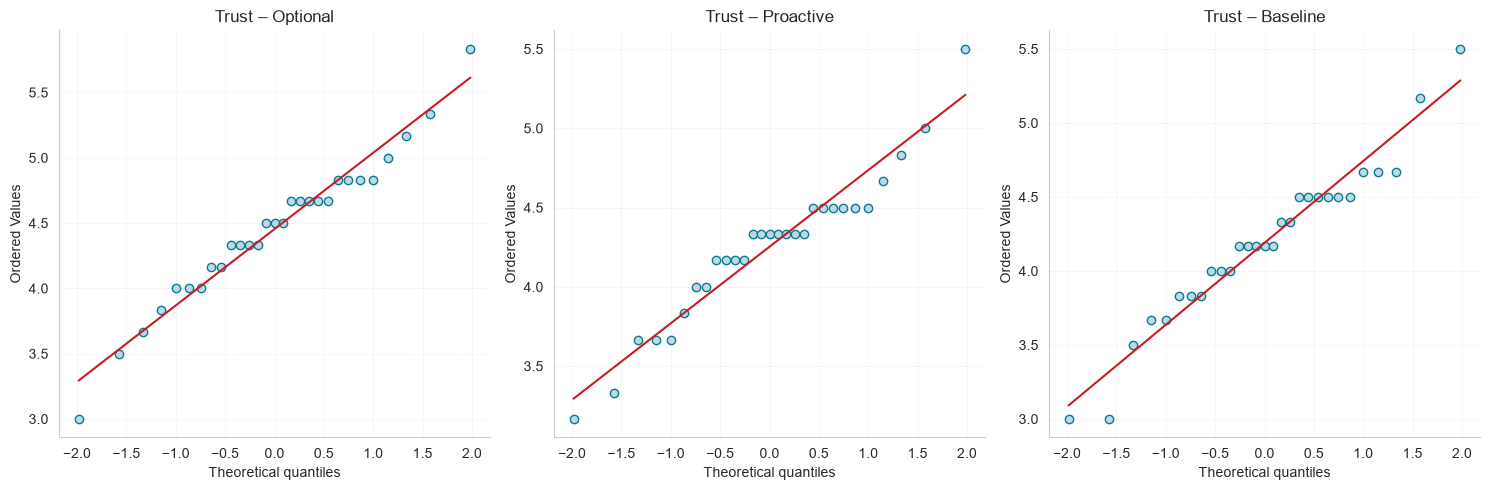

In [6]:
plot_qq_by_condition(df, dv="trust", title="Trust")
#plot_qq_by_condition(df, dv="understanding", title="System Understanding")
#plot_qq_by_condition(df, dv="nasa", title="NASA-TLX")


# Assumption Check: Sphericity

Mauchly's test of sphericity was conducted for the repeated-measures ANOVAs to assess whether the sphericity assumption was met.
The test was applied to trust and system understanding, which were analysed using repeated-measures ANOVA.

In [7]:
for dv in ["trust", "understanding"]:
    print(f"\n{'='*50}")
    print(f"{dv.upper()}")
    print(f"{'='*50}")

    sphericity = pg.sphericity(
        data=df,
        dv=dv,
        subject="participant_id",
        within="condition"
    )

    print(
        f"Mauchly's test: "
        f"W = {sphericity.W:.3f}, "
        f"χ²({sphericity.dof}) = {sphericity.chi2:.3f}, "
        f"p = {sphericity.pval:.4f}"
    )



TRUST
Mauchly's test: W = 0.999, χ²(2) = 0.028, p = 0.9862

UNDERSTANDING
Mauchly's test: W = 0.910, χ²(2) = 2.534, p = 0.2816


# Repeated-Measures ANOVA

Repeated-measures ANOVAs were conducted for trust and system understanding to test whether explanation condition affected the dependent variables.

Effect sizes are reported as partial eta squared (η²ₚ).

In [8]:
for dv in ["trust", "understanding"]:
    print(f"\n{'='*50}")
    print(f"{dv.upper()}")
    print(f"{'='*50}")

    aov = pg.rm_anova(
        data=df,
        dv=dv,
        within="condition",
        subject="participant_id",
        detailed=True,
        effsize="np2"
    )

    effect = aov.iloc[0]
    error = aov.iloc[1]

    print(
        f"F({int(effect['DF'])}, {int(error['DF'])}) = "
        f"{effect['F']:.3f}, "
        f"p = {effect['p_unc']:.4f}, "
        f"η²ₚ = {effect['np2']:.3f}"
    )



TRUST
F(2, 56) = 3.607, p = 0.0336, η²ₚ = 0.114

UNDERSTANDING
F(2, 56) = 11.208, p = 0.0001, η²ₚ = 0.286


# Post-hoc Analysis: Paired-Samples t-tests

Paired-samples t-tests were conducted for pairwise comparisons between explanation conditions.
p-values were corrected for multiple comparisons using the Holm-Bonferroni correction.

In [9]:
for dv in ["trust", "understanding"]:
    print(f"\n{'='*50}")
    print(f"{dv.upper()}")
    print(f"{'='*50}")

    results = paired_ttests(df, dv)

    for pair, r in results.items():
        print(
            f"{pair[0]} vs {pair[1]}: "
            f"t({r['n']-1}) = {r['t']:.3f}, "
            f"p_raw = {r['p_raw']:.4f}, "
            f"p_holm = {r['p_holm']:.4f}, "
            f"{r['sig']}"
        )



TRUST
Baseline vs Proactive: t(28) = -0.611, p_raw = 0.5461, p_holm = 0.5461, ns
Baseline vs Optional: t(28) = -2.614, p_raw = 0.0142, p_holm = 0.0427, *
Proactive vs Optional: t(28) = -1.938, p_raw = 0.0627, p_holm = 0.1254, ns

UNDERSTANDING
Baseline vs Proactive: t(28) = -3.888, p_raw = 0.0006, p_holm = 0.0017, **
Baseline vs Optional: t(28) = -3.750, p_raw = 0.0008, p_holm = 0.0017, **
Proactive vs Optional: t(28) = 0.357, p_raw = 0.7237, p_holm = 0.7237, ns


# Non-parametric Analysis: Friedman Test

Due to violations of the normality assumption, NASA-TLX scores were analysed using a Friedman test as a non-parametric alternative to the repeated-measures ANOVA.

In [10]:
friedman = pg.friedman(
    data=df,
    dv="nasa",
    within="condition",
    subject="participant_id"
)

result = friedman.iloc[0]

print(
    f"\n{'='*50}"
     "\nNASA\n"
    f"{'='*50}\n"
    f"χ²({int(result['ddof1'])}) = "
    f"{result['Q']:.3f}, "
    f"p = {result['p_unc']:.4f}, "
    f"Kendall's W = {result['W']:.3f}"
)



NASA
χ²(2) = 1.130, p = 0.5685, Kendall's W = 0.019


## Boxplots

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Optional vs. Baseline: t-test paired samples with Bonferroni correction, P_val:1.425e-02 t=2.614e+00


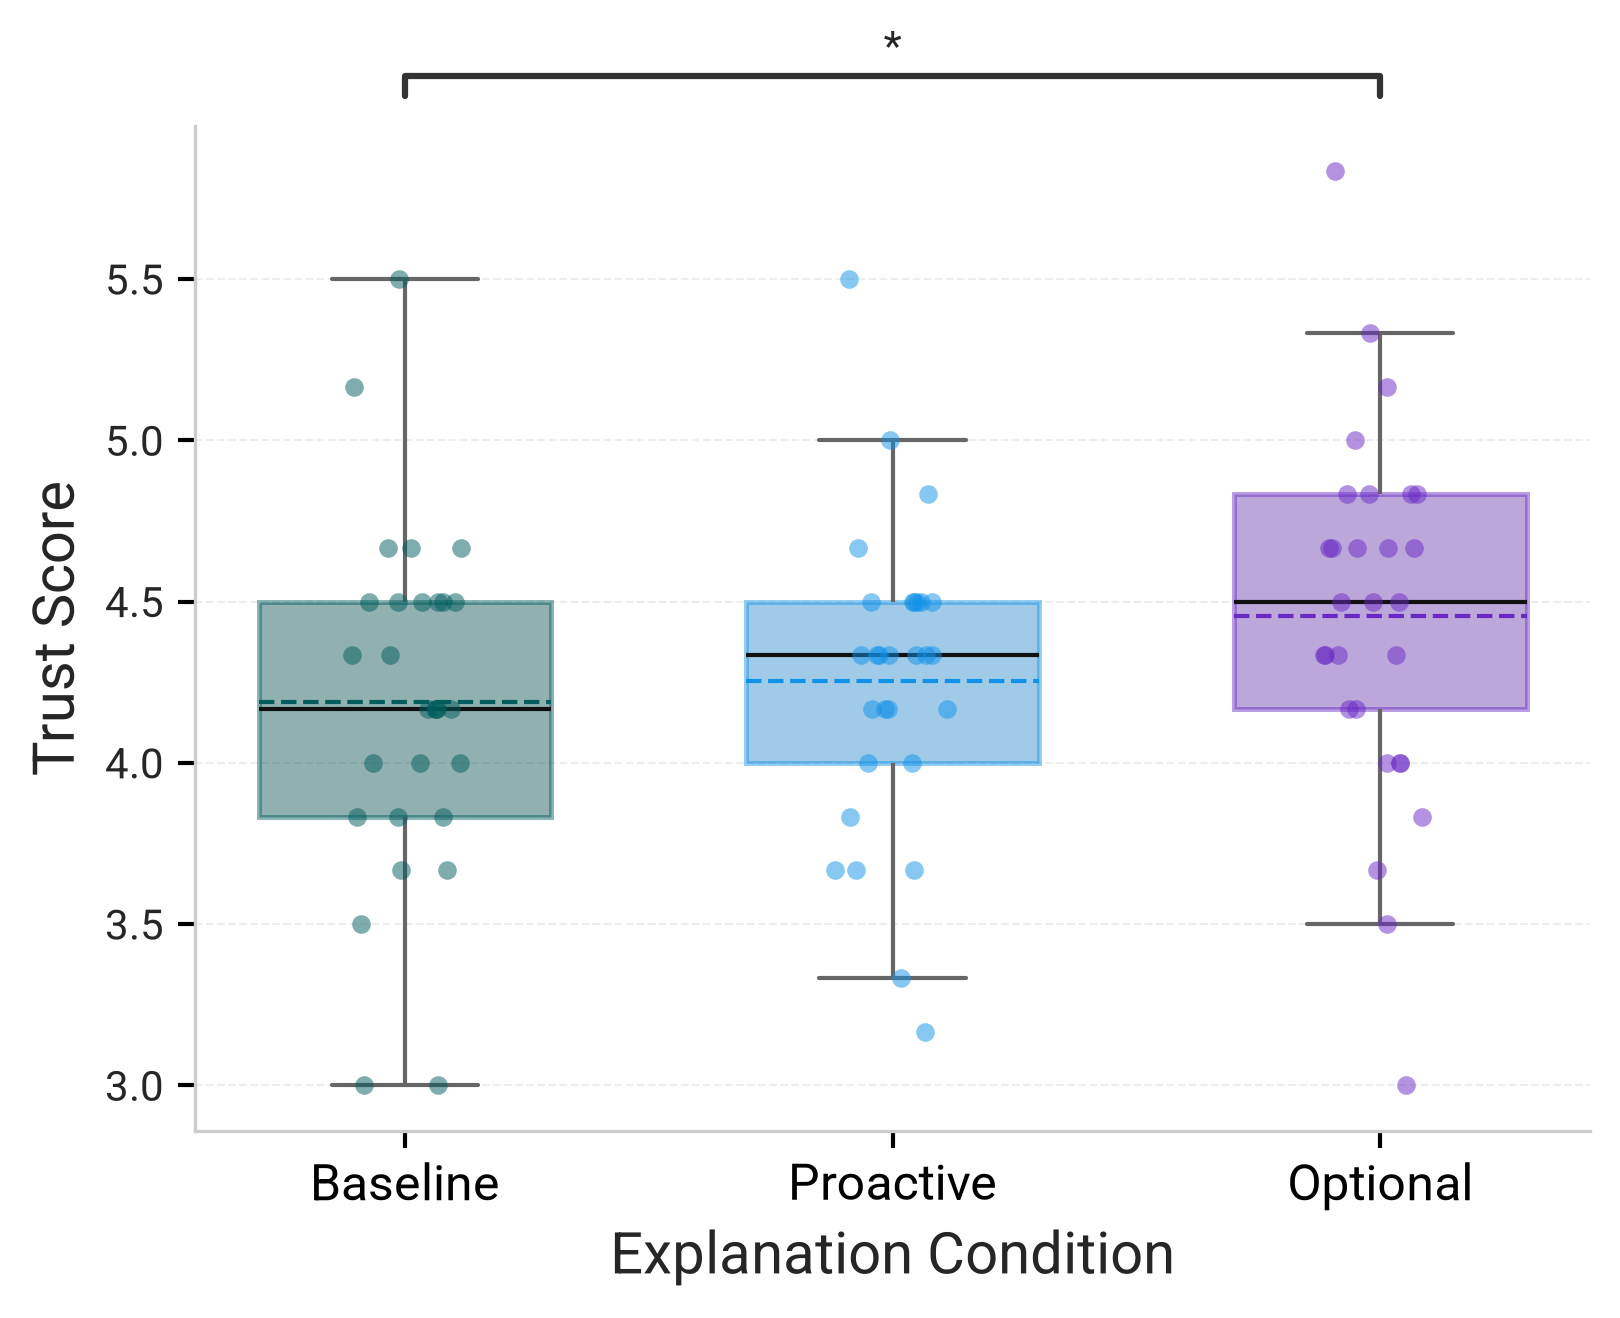

In [11]:
stylised_boxplot(df, "trust")
#stylised_boxplot(df, "nasa")
#stylised_boxplot(df, "understanding")


# Explanation vs No Explanation

The two explanation conditions were collapsed into a single explanation condition.
A paired comparison was conducted against the baseline condition.

In [12]:
df_grouped = df.copy()

df_grouped["explanation_group"] = df_grouped["condition"].replace({
    "Optional": "Explanation",
    "Proactive": "Explanation",
    "Baseline": "No Explanation"
})

# average within participant + group
summary = (
    df_grouped
    .groupby(["participant_id", "explanation_group"])["trust"]
    .mean()
    .reset_index()
)

# pivot to wide format
pivot = summary.pivot(
    index="participant_id",
    columns="explanation_group",
    values="trust"
)

diff = pivot["Explanation"] - pivot["No Explanation"]

# Normality check
stat, p = shapiro(diff)

print(f"Shapiro-Wilk: W = {stat:.3f}, p = {p:.4f}")


Shapiro-Wilk: W = 0.964, p = 0.4029


In [13]:
#paired t-test
t, p = ttest_rel(
    pivot["Explanation"],
    pivot["No Explanation"]
)

# effect size
cohens_d = diff.mean() / diff.std(ddof=1)

print(
    f"Paired t-test: "
    f"t({len(diff)-1}) = {t:.3f}, "
    f"p = {p:.4f}, "
    f"Cohen's d_z = {cohens_d:.3f}"
)


Paired t-test: t(28) = 1.858, p = 0.0738, Cohen's d_z = 0.345



TRUST descriptive statistics (grouped):
No Explanation: M = 4.19, SD = 0.55, N = 29
Explanation: M = 4.35, SD = 0.45, N = 29
Paired t-test: t = 1.858, p = 0.0738
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

No Explanation vs. Explanation: t-test paired samples, P_val:7.375e-02 t=-1.858e+00


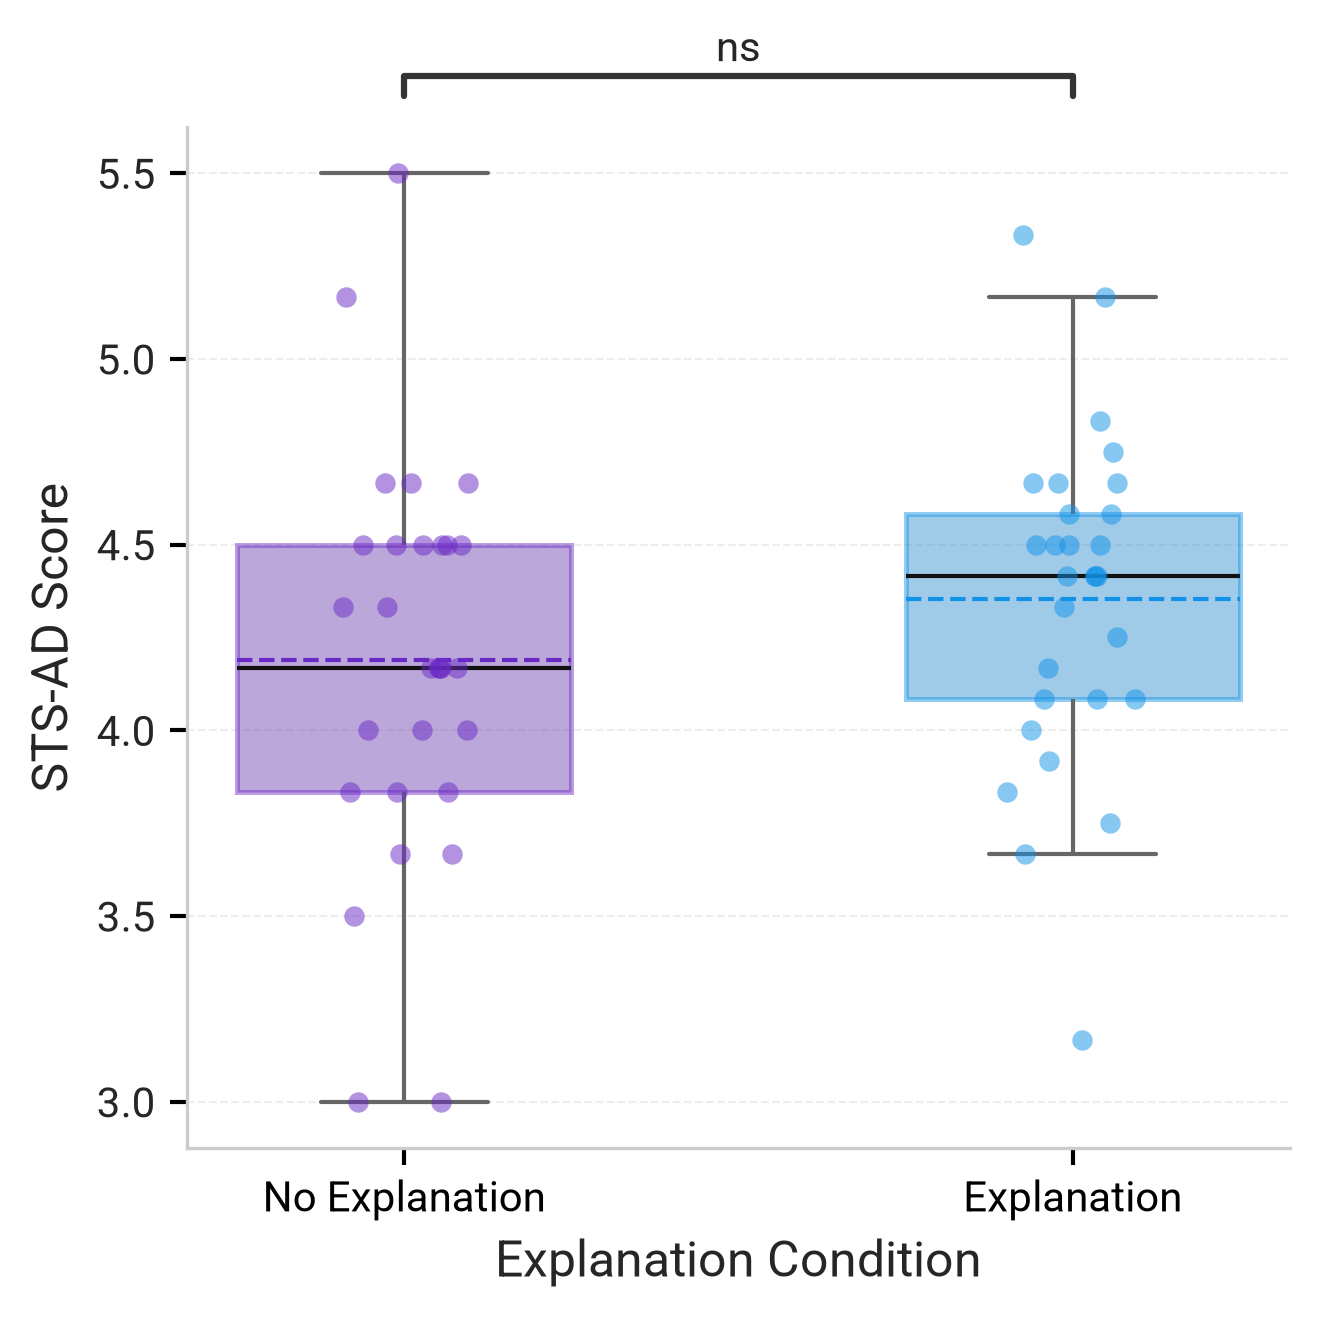

In [14]:
stylised_boxplot_grouped(df, "trust")
